# # 07 — Cannibalization (MVP 04)
#
# **Pipeline stage: campaign-level cannibalization intelligence on top of Product Intelligence.**
#
# This notebook **reuses** the Product Intelligence pipeline (`03_product_intelligence.ipynb`)
# and does **not** recreate relationship labels or heuristic classifiers. It consumes:
#
# - `product_relationships.parquet` — ML-scored substitution / complementary pairs
# - `product_pair_features.parquet` — pairwise relationship feature store
# - `relationship_explanations.parquet` — explainability evidence per pair
# - `temporal_relationships.parquet` — time-block correlation of demand
# - `product_embeddings.parquet` / `product_features.parquet` — product representations
#
# and adds the **campaign layer**: which products were promoted, which related products
# lost volume during the campaign, how confident we are, and what evidence supports it.
#
# ```
# PI relationship graph + promotion history (MVP 01) + product-day sales
#   -> relationship graph over substitution edges
#   -> expected-vs-actual impact per (campaign, promoted, affected) triple
#   -> business-friendly report (affected products, confidence, evidence, impact)
#   -> causal-ready panel export for future inference
#   -> campaign_cannibalization.parquet | cannibalization_report.json | panel
# ```


In [1]:
# --- environment --------------------------------------------------------------
import sys
import json
import warnings
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

def _find_root() -> Path:
    p = Path.cwd()
    for q in [p, *p.parents]:
        if (q / "data" / "raw" / "transaction_data.csv").exists():
            return q
    return p

ROOT = _find_root()
sys.path.insert(0, str(ROOT / "notebooks"))

from utils import data as UD
from utils import common as UC

logger = UC.setup_logging("cannibalization")


@dataclass(frozen=True)
class Config:
    """Single source of truth for MVP 04."""
    pi_dir: Path = UC.OUTPUTS_ROOT / "product_intelligence"
    promo_dir: Path = UC.OUTPUTS_ROOT / "promotion_analysis"
    seed: int = 42
    pre_days: int = 28                    # baseline window before campaign start
    top_promoted_per_campaign: int = 25   # promoted products analysed per campaign
    top_neighbors_per_promoted: int = 5   # substitution neighbours per promoted product
    min_relationship_confidence: float = 0.50
    min_pre_sales: float = 1.0            # affected product needs this much pre-window sales
    z_conf: float = 1.96
    trend_clip: tuple = (0.5, 2.0)        # guard against extreme retailer-level trends
    output_dir: Path = UC.pipeline_dir("cannibalization")
    figures_dir: Path = UC.figures_dir("cannibalization")


CFG = Config()
UC.set_seed(CFG.seed)
print(f"PI inputs     : {CFG.pi_dir}")
print(f"Output dir    : {CFG.output_dir}")


PI inputs     : /home/mhseddighi/Projects/promotion-intelligence/outputs/product_intelligence
Output dir    : /home/mhseddighi/Projects/promotion-intelligence/outputs/cannibalization


# ## 1. Load Product Intelligence Artifacts
#
# The relationship model, pair features, temporal analysis and explanations are all
# loaded read-only. If the Product Intelligence pipeline has not been run, we fail with
# an actionable message instead of silently degrading.


In [2]:
REQUIRED_PI = ["product_relationships.parquet", "product_pair_features.parquet",
               "relationship_explanations.parquet", "temporal_relationships.parquet",
               "product_embeddings.parquet", "product_features.parquet"]
missing = [f for f in REQUIRED_PI if not (CFG.pi_dir / f).exists()]
if missing:
    raise FileNotFoundError(
        f"Missing Product Intelligence artifacts: {missing}. "
        f"Run notebooks/03_product_intelligence.ipynb first."
    )

relationships = pd.read_parquet(CFG.pi_dir / "product_relationships.parquet")
pair_features = pd.read_parquet(CFG.pi_dir / "product_pair_features.parquet")
explanations = pd.read_parquet(CFG.pi_dir / "relationship_explanations.parquet")
temporal = pd.read_parquet(CFG.pi_dir / "temporal_relationships.parquet")
embeddings = pd.read_parquet(CFG.pi_dir / "product_embeddings.parquet")
product_features = pd.read_parquet(CFG.pi_dir / "product_features.parquet")

print(f"relationships           : {relationships.shape}")
print(f"pair_features           : {pair_features.shape}")
print(f"explanations            : {explanations.shape}")
print(f"temporal_relationships  : {temporal.shape}")
print(f"embeddings              : {embeddings.shape}")


relationships           : (360524, 10)
pair_features           : (360524, 34)
explanations            : (75, 9)
temporal_relationships  : (650, 9)
embeddings              : (92353, 129)


In [3]:
def validate_pi() -> None:
    UC.check_schema(relationships, ["product_a", "product_b", "substitution_score",
                                    "confidence_score", "substitution_rank"],
                    context="product_relationships")
    UC.check_schema(pair_features, ["product_a", "product_b", "shared_customers",
                                    "customer_overlap", "basket_jaccard", "lift",
                                    "sales_corr"], context="product_pair_features")
    UC.check_schema(explanations, ["product_a", "product_b", "feature", "contribution",
                                   "direction"], context="relationship_explanations")
    UC.check_schema(temporal, ["product_a", "product_b", "block_corr"],
                    context="temporal_relationships")
    UC.check_schema(embeddings, ["PRODUCT_ID"], context="product_embeddings")
    UC.check_no_nan_inf(relationships, context="product_relationships",
                        cols=["product_a", "product_b", "substitution_score",
                              "confidence_score"])
    assert relationships["substitution_score"].between(0, 1).all()
    assert len(relationships) > 100_000
    print("PASS: Product Intelligence artifacts validated")


validate_pi()


PASS [schema] product_relationships: 10 columns OK
PASS [schema] product_pair_features: 34 columns OK
PASS [schema] relationship_explanations: 9 columns OK
PASS [schema] temporal_relationships: 9 columns OK
PASS [schema] product_embeddings: 129 columns OK
PASS [nan/inf] product_relationships: no NaN/Inf in 360,524 rows
PASS: Product Intelligence artifacts validated


# ## 2. Relationship Graph
#
# Substitution edges become a directed lookup graph (`promoted -> affected`). Each edge
# carries the ML substitution score and relationship confidence. The graph is built
# once and reused for every campaign — no per-campaign model fitting.


In [4]:
sub = relationships[["product_a", "product_b", "substitution_score", "confidence_score",
                     "relationship_score", "substitution_rank"]]
rel_undir = pd.concat([
    sub.rename(columns={"product_a": "promoted_pid", "product_b": "affected_pid"}),
    sub.rename(columns={"product_b": "promoted_pid", "product_a": "affected_pid"}),
], ignore_index=True)

import networkx as nx
G = nx.from_pandas_edgelist(
    sub, source="product_a", target="product_b",
    edge_attr=["substitution_score", "confidence_score"])
print(f"Graph nodes (products)  : {G.number_of_nodes():,}")
print(f"Graph edges (pairs)     : {G.number_of_edges():,}")
print(f"Connected components    : {nx.number_connected_components(G):,}")
deg = pd.Series(dict(G.degree()))
print(f"Degree stats            : mean={deg.mean():.1f} median={deg.median():.0f} max={deg.max():,}")


Graph nodes (products)  : 18,661
Graph edges (pairs)     : 360,524


Connected components    : 1
Degree stats            : mean=38.6 median=32 max=308


In [5]:
def validate_graph() -> None:
    assert G.number_of_nodes() > 10_000, "relationship graph too small"
    assert G.number_of_edges() > 100_000, "relationship graph too sparse"
    print("PASS: relationship graph built")


validate_graph()


PASS: relationship graph built


# ## 3. Campaign x Promoted x Affected Triples
#
# For every campaign we take its top promoted products (by discounted sales) and look up
# their strongest substitution neighbours. Neighbours that are *themselves* promoted in
# the same campaign are excluded (their volume change is attributable to their own
# promotion, not cannibalization).


In [6]:
promoted = pd.read_parquet(CFG.promo_dir / "promoted_products.parquet")
product_daily = pd.read_parquet(CFG.promo_dir / "product_daily.parquet")
products = UD.load_products()
campaign_desc = UD.campaign_days(UD.load_campaign_desc())
summary = pd.read_parquet(CFG.promo_dir / "campaign_summary.parquet")

top_promo = (promoted.sort_values("promo_sales", ascending=False)
                     .groupby("CAMPAIGN", as_index=False)
                     .head(CFG.top_promoted_per_campaign))
pairs = (top_promo[["CAMPAIGN", "PRODUCT_ID", "START_DAY", "END_DAY", "promo_sales"]]
         .rename(columns={"PRODUCT_ID": "promoted_pid"})
         .merge(rel_undir, on="promoted_pid", how="inner"))
pairs = pairs[pairs["substitution_rank"] <= CFG.top_neighbors_per_promoted]
pairs = pairs[pairs["confidence_score"] >= CFG.min_relationship_confidence]

# exclude affected products promoted in the same campaign
promoted_set = {cid: set(g["PRODUCT_ID"]) for cid, g in promoted.groupby("CAMPAIGN")}
pairs = pairs[pairs.apply(lambda r: r["affected_pid"] not in promoted_set.get(int(r["CAMPAIGN"]), set()),
                          axis=1)]

# evidence: merge pairwise relationship features
ev = pair_features[["product_a", "product_b", "shared_customers", "customer_overlap",
                    "basket_jaccard", "lift", "sales_corr", "price_corr",
                    "same_commodity", "same_department"]]
pairs = (pairs.merge(ev.rename(columns={"product_a": "promoted_pid", "product_b": "affected_pid"}),
                     on=["promoted_pid", "affected_pid"], how="left")
             .merge(ev.rename(columns={"product_b": "promoted_pid", "product_a": "affected_pid"}),
                    on=["promoted_pid", "affected_pid"], how="left", suffixes=("", "_rev")))

# temporal evidence: mean block correlation per pair
temporal_agg = (temporal.groupby(["product_a", "product_b"], as_index=False)["block_corr"].mean())
pairs = (pairs.merge(temporal_agg.rename(columns={"product_a": "promoted_pid",
                                                 "product_b": "affected_pid"}),
                     on=["promoted_pid", "affected_pid"], how="left"))

pairs["end_eff"] = pairs["END_DAY"].clip(upper=int(product_daily["DAY"].max()))
print(f"Triples (campaign x promoted x affected): {len(pairs):,}")
print(f"Covered campaigns: {pairs['CAMPAIGN'].nunique()} / {len(campaign_desc)}")
print(pairs[["CAMPAIGN", "promoted_pid", "affected_pid", "substitution_score",
             "confidence_score"]].head().to_string(index=False))


Triples (campaign x promoted x affected): 1,637
Covered campaigns: 30 / 30
 CAMPAIGN  promoted_pid  affected_pid  substitution_score  confidence_score
       24       6534178       5703832                 1.0          0.680465
       12       6534178       5703832                 1.0          0.680465
       16       6534178       5703832                 1.0          0.680465
       25       6534178       5703832                 1.0          0.680465
       15        916122        945901                 1.0          0.595133


In [7]:
def validate_pairs() -> None:
    assert not pairs.empty
    assert pairs["substitution_score"].between(0, 1).all()
    assert pairs["confidence_score"].between(0, 1).all()
    # no self-pairs and no co-promoted pairs survive
    assert (pairs["promoted_pid"] != pairs["affected_pid"]).all()
    UC.check_no_nan_inf(pairs[["CAMPAIGN", "promoted_pid", "affected_pid",
                               "substitution_score", "confidence_score"]],
                        context="triples")
    print("PASS: candidate triples validated")


validate_pairs()


PASS [nan/inf] triples: no NaN/Inf in 1,637 rows
PASS: candidate triples validated


# ## 4. Impact Estimation (Expected vs Actual)
#
# For each affected product we compare what it *should* have sold during the campaign
# window (28-day pre-window daily mean, scaled by the retailer-level volume trend) with
# what it actually sold:
#
# ```
# expected = pre_daily_mean_qty × during_days × retailer_trend_ratio
# impact   = expected − actual          (positive → lost volume → cannibalization)
# ```
#
# A 95% confidence interval is built from the pre-window daily variance. This is a
# transparent, explainable estimator — and the exported **panel** keeps the raw
# pre/during/post data so a future causal layer (DiD / synthetic control) can upgrade
# the estimator without changing the rest of the pipeline.


In [8]:
summary["trend_ratio"] = (summary["during_qty_daily"] / summary["pre_qty_daily"]).clip(
    *CFG.trend_clip)
trend_map = dict(zip(summary["CAMPAIGN"], summary["trend_ratio"]))

pairs["pre_start"] = (pairs["START_DAY"] - CFG.pre_days).clip(lower=1)
pairs["trend_ratio"] = pairs["CAMPAIGN"].map(trend_map).fillna(1.0)
pairs["during_days"] = pairs["end_eff"] - pairs["START_DAY"] + 1

# pre-window stats per (campaign, affected)
m = pairs[["CAMPAIGN", "promoted_pid", "affected_pid", "pre_start", "START_DAY",
           "end_eff", "during_days", "trend_ratio"]].merge(
    product_daily.rename(columns={"PRODUCT_ID": "affected_pid"}), on="affected_pid", how="left")
pre = (m[(m["DAY"] >= m["pre_start"]) & (m["DAY"] < m["START_DAY"])]
       .groupby(["CAMPAIGN", "promoted_pid", "affected_pid"], as_index=False)
       .agg(pre_daily_mean_qty=("quantity", "mean"),
            pre_daily_std_qty=("quantity", "std"),
            pre_sales=("sales_value", "sum"),
            pre_qty=("quantity", "sum"),
            pre_days=("DAY", "nunique")))
dur = (m[(m["DAY"] >= m["START_DAY"]) & (m["DAY"] <= m["end_eff"])]
       .groupby(["CAMPAIGN", "promoted_pid", "affected_pid"], as_index=False)
       .agg(actual_qty=("quantity", "sum"), actual_sales=("sales_value", "sum")))

panel = (pairs.merge(pre, on=["CAMPAIGN", "promoted_pid", "affected_pid"], how="left")
              .merge(dur, on=["CAMPAIGN", "promoted_pid", "affected_pid"], how="left"))
panel["pre_daily_mean_qty"] = panel["pre_daily_mean_qty"].fillna(0.0)
panel["pre_daily_std_qty"] = panel["pre_daily_std_qty"].fillna(0.0)
panel["actual_qty"] = panel["actual_qty"].fillna(0.0)
panel["actual_sales"] = panel["actual_sales"].fillna(0.0)

panel["expected_qty"] = panel["pre_daily_mean_qty"] * panel["during_days"] * panel["trend_ratio"]
panel["impact_qty"] = panel["expected_qty"] - panel["actual_qty"]
panel["avg_price"] = np.where(panel["pre_qty"] > 0, panel["pre_sales"] / panel["pre_qty"], 0.0)
panel["impact_revenue"] = panel["impact_qty"] * panel["avg_price"]
se = panel["pre_daily_std_qty"] * np.sqrt(panel["during_days"]) * panel["trend_ratio"]
panel["ci_low_qty"] = panel["impact_qty"] - CFG.z_conf * se
panel["ci_high_qty"] = panel["impact_qty"] + CFG.z_conf * se
z = np.where(se > 0, panel["impact_qty"] / se, 0.0)
stat_conf = np.clip(0.5 + 0.5 * (1 - np.exp(-np.abs(z) / 2.0)), 0.5, 0.99)
panel["stat_confidence"] = stat_conf
panel["combined_confidence"] = np.sqrt(stat_conf * panel["confidence_score"])

# keep only products with meaningful pre-window presence
panel = panel[panel["pre_sales"] >= CFG.min_pre_sales].reset_index(drop=True)
UC.save_parquet(panel, CFG.output_dir / "cannibalization_panel.parquet",
                logger=logger, context="cannibalization_panel")
print(f"Panel rows: {len(panel):,}")
print(panel[["CAMPAIGN", "promoted_pid", "affected_pid", "expected_qty", "actual_qty",
             "impact_qty", "impact_revenue", "combined_confidence"]]
      .sort_values("impact_revenue", ascending=False).head(8).to_string(index=False))


22:57:39 | INFO    | cannibalization | [cannibalization_panel] WROTE /home/mhseddighi/Projects/promotion-intelligence/outputs/cannibalization/cannibalization_panel.parquet (1,264 rows x 46 cols)


Panel rows: 1,264
 CAMPAIGN  promoted_pid  affected_pid  expected_qty  actual_qty    impact_qty  impact_revenue  combined_confidence
       30        982469        886991    181.735953         0.0    181.735953     3723.769645             0.533494
        7        982469       5571176    152.065425         0.0    152.065425     1553.348335             0.624994
       12       6534178       5703832 523992.235648         0.0 523992.235648     1487.788151             0.820768
       11       1044078       1012514    109.570859         4.0    105.570859     1477.342348             0.753576
       11       1000753       1012514    109.570859         4.0    105.570859     1477.342348             0.813684
       15        844179        831407    207.067135        40.0    167.067135     1466.014042             0.801192
       14       1000753       1107420     89.344641        11.0     78.344641     1254.297695             0.752493
       14       1070702       1107420     89.344641        11.

In [9]:
def validate_panel() -> None:
    assert not panel.empty
    optional_nan = ["ci_low_qty", "ci_high_qty", "shared_customers", "shared_customers_rev",
                    "customer_overlap", "customer_overlap_rev",
                    "basket_jaccard", "basket_jaccard_rev", "lift", "lift_rev",
                    "sales_corr", "sales_corr_rev", "price_corr", "price_corr_rev",
                    "same_commodity", "same_commodity_rev", "same_department",
                    "same_department_rev", "block_corr", "feature", "label",
                    "direction", "feature_value"]
    UC.check_no_nan_inf(panel, context="cannibalization_panel",
                        allow_nan_cols=optional_nan)
    assert (panel["combined_confidence"].between(0, 1)).all()
    assert (panel["actual_qty"] >= 0).all() and (panel["expected_qty"] >= 0).all()
    # reload contract
    reloaded = UC.reload_and_check(CFG.output_dir / "cannibalization_panel.parquet",
        expected=["CAMPAIGN", "promoted_pid", "affected_pid", "expected_qty",
                  "actual_qty", "impact_qty", "impact_revenue", "combined_confidence"],
        context="panel")
    assert len(reloaded) == len(panel)
    print("PASS: impact panel validated")


validate_panel()


PASS [nan/inf] cannibalization_panel: no NaN/Inf in 1,264 rows
PASS [nan/inf] reload cannibalization_panel.parquet: no NaN/Inf in 1,264 rows
PASS [schema] reload cannibalization_panel.parquet: 46 columns OK
PASS [reload] panel: cannibalization_panel.parquet -> 1,264 rows
PASS: impact panel validated


# ## 5. Business-Friendly Report
#
# Aggregated per **affected product** (a product can be cannibalized by several promoted
# products). Each row carries the estimated lost volume / revenue, the strongest
# evidence and the top contributing source.


In [10]:
cann = panel[panel["impact_qty"] > 0].copy()
agg = (cann.groupby(["CAMPAIGN", "affected_pid"], as_index=False)
         .agg(lost_qty=("impact_qty", "sum"),
              lost_revenue=("impact_revenue", "sum"),
              n_sources=("promoted_pid", "nunique"),
              max_confidence=("combined_confidence", "max"),
              mean_substitution_score=("substitution_score", "mean"),
              mean_customer_overlap=("customer_overlap", "mean"),
              mean_basket_jaccard=("basket_jaccard", "mean"),
              mean_lift=("lift", "mean"),
              mean_sales_corr=("sales_corr", "mean"),
              mean_block_corr=("block_corr", "mean"),
              top_source=("promoted_pid", lambda s: int(s.iloc[np.argmax(cann.loc[s.index, "impact_qty"])]))))
agg = agg.merge(products[["PRODUCT_ID", "COMMODITY_DESC", "DEPARTMENT", "BRAND"]],
                left_on="affected_pid", right_on="PRODUCT_ID", how="left")
agg = agg.sort_values(["CAMPAIGN", "lost_revenue"], ascending=[True, False]).reset_index(drop=True)
UC.save_parquet(agg, CFG.output_dir / "campaign_cannibalization.parquet",
                logger=logger, context="campaign_cannibalization")
print(f"Affected-product rows: {len(agg):,}")
print(agg[["CAMPAIGN", "affected_pid", "COMMODITY_DESC", "lost_qty", "lost_revenue",
           "n_sources", "max_confidence", "top_source"]].head(10).to_string(index=False))


22:57:40 | INFO    | cannibalization | [campaign_cannibalization] WROTE /home/mhseddighi/Projects/promotion-intelligence/outputs/cannibalization/campaign_cannibalization.parquet (994 rows x 17 cols)


Affected-product rows: 994
 CAMPAIGN  affected_pid COMMODITY_DESC   lost_qty  lost_revenue  n_sources  max_confidence  top_source
        1        853887           BEEF  76.738768   1168.347775          2        0.578181      844179
        1       1012514           BEEF  74.738768   1038.868850          2        0.557807     1044078
        1      12812261           PORK  77.738768    769.891410          1        0.796560    12810391
        1        835028           BEEF  72.738768    753.209912          2        0.549768      844179
        1      12810389           PORK  54.054076    675.856125          1        0.740190    12810391
        1       1107420           BEEF  50.054076    621.671662          1        0.722294     1070702
        1       9837478           PORK  76.738768    591.655906          2        0.617714    12810391
        1       9835747           PORK  72.738768    541.176440          2        0.640960    12810391
        1      12811993           PORK 130.231

In [11]:
def validate_report_table() -> None:
    assert len(agg) > 0
    assert (agg["lost_qty"] > 0).all() and (agg["lost_revenue"] >= 0).all()
    UC.check_no_nan_inf(agg, context="campaign_cannibalization",
                        allow_nan_cols=["mean_block_corr", "mean_lift",
                                        "mean_customer_overlap", "mean_basket_jaccard",
                                        "mean_sales_corr"])
    UC.check_schema(agg, ["CAMPAIGN", "affected_pid", "lost_qty", "lost_revenue",
                          "max_confidence", "top_source"], context="campaign_cannibalization")
    print("PASS: report table validated")


validate_report_table()


PASS [nan/inf] campaign_cannibalization: no NaN/Inf in 994 rows
PASS [schema] campaign_cannibalization: 17 columns OK
PASS: report table validated


In [12]:
# Explanation evidence per pair: strongest contributing feature (top |contribution|)
expl_top = (explanations.assign(contribution=explanations["contribution"].abs())
            .sort_values("contribution", ascending=False)
            .groupby(["product_a", "product_b"], as_index=False).first()
            [["product_a", "product_b", "feature", "label", "direction", "feature_value"]])
expl_top = pd.concat([
    expl_top.rename(columns={"product_a": "promoted_pid", "product_b": "affected_pid"}),
], ignore_index=True)
panel = panel.merge(expl_top, on=["promoted_pid", "affected_pid"], how="left")

# LLM-ready JSON report
cann = cann.merge(expl_top, on=["promoted_pid", "affected_pid"], how="left")
report = {}
for cid, g in cann.groupby("CAMPAIGN"):
    affected = []
    for _, r in g.sort_values("impact_revenue", ascending=False).head(10).iterrows():
        affected.append({
            "affected_product_id": int(r["affected_pid"]),
            "promoted_product_id": int(r["promoted_pid"]),
            "estimated_lost_qty": round(float(r["impact_qty"]), 1),
            "estimated_lost_revenue": round(float(r["impact_revenue"]), 2),
            "confidence": round(float(r["combined_confidence"]), 3),
            "evidence": {
                "substitution_score": round(float(r["substitution_score"]), 3),
                "customer_overlap": None if pd.isna(r["customer_overlap"]) else round(float(r["customer_overlap"]), 3),
                "basket_jaccard": None if pd.isna(r["basket_jaccard"]) else round(float(r["basket_jaccard"]), 3),
                "sales_corr": None if pd.isna(r["sales_corr"]) else round(float(r["sales_corr"]), 3),
                "temporal_block_corr": None if pd.isna(r["block_corr"]) else round(float(r["block_corr"]), 3),
                "top_explaining_feature": r["label"] if pd.notna(r["label"]) else None,
                "feature_direction": r["direction"] if pd.notna(r["direction"]) else None,
            },
        })
    total_lost = float(g["impact_revenue"].sum())
    report[int(cid)] = {
        "campaign_id": int(cid),
        "n_affected_pairs": int(len(g)),
        "total_estimated_lost_revenue": round(total_lost, 2),
        "affected_products": affected,
    }
UC.save_json(report, CFG.output_dir / "cannibalization_report.json",
             logger=logger, context="cannibalization_report")
print(f"Report covers {len(report)} campaigns")


22:57:40 | INFO    | cannibalization | [cannibalization_report] WROTE /home/mhseddighi/Projects/promotion-intelligence/outputs/cannibalization/cannibalization_report.json


Report covers 30 campaigns


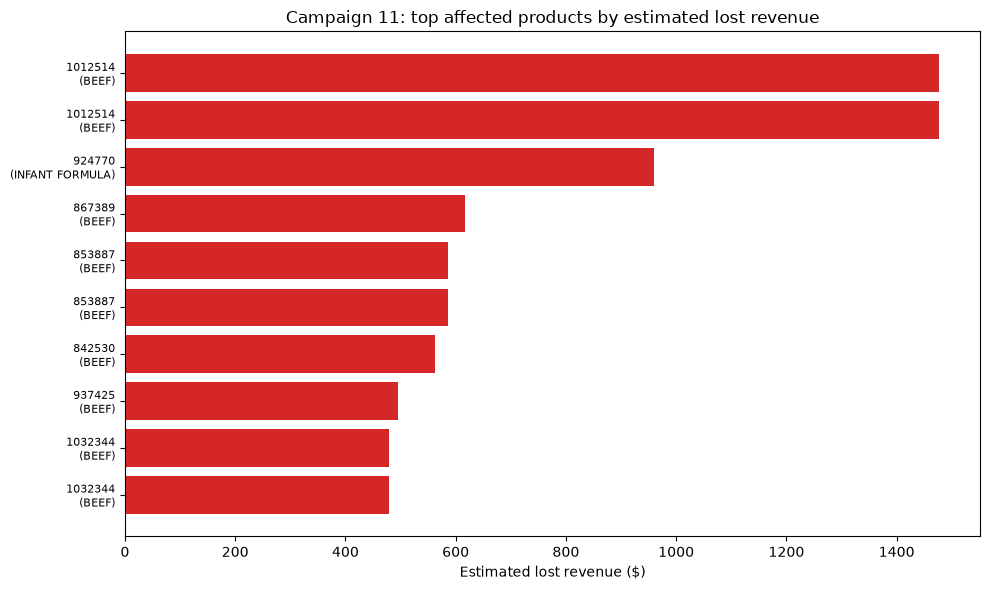

In [13]:
# Figure 1: top affected products for the most cannibalizing campaign
top_camp = int(cann.groupby("CAMPAIGN")["impact_revenue"].sum().idxmax())
top_rows = cann[cann["CAMPAIGN"] == top_camp].sort_values("impact_revenue", ascending=False).head(10)
top_rows = top_rows.merge(products[["PRODUCT_ID", "COMMODITY_DESC"]],
                          left_on="affected_pid", right_on="PRODUCT_ID", how="left")

fig, ax = plt.subplots(figsize=(10, 6))
labels = [f"{r['affected_pid']}\n({str(r['COMMODITY_DESC'])[:22]})" for _, r in top_rows.iterrows()]
ax.barh(range(len(top_rows)), top_rows["impact_revenue"], color="#d62728")
ax.set_yticks(range(len(top_rows))); ax.set_yticklabels(labels, fontsize=8)
ax.invert_yaxis()
ax.set_title(f"Campaign {top_camp}: top affected products by estimated lost revenue")
ax.set_xlabel("Estimated lost revenue ($)")
plt.tight_layout()
fig.savefig(CFG.figures_dir / "top_affected_products.png", dpi=110)
plt.show()


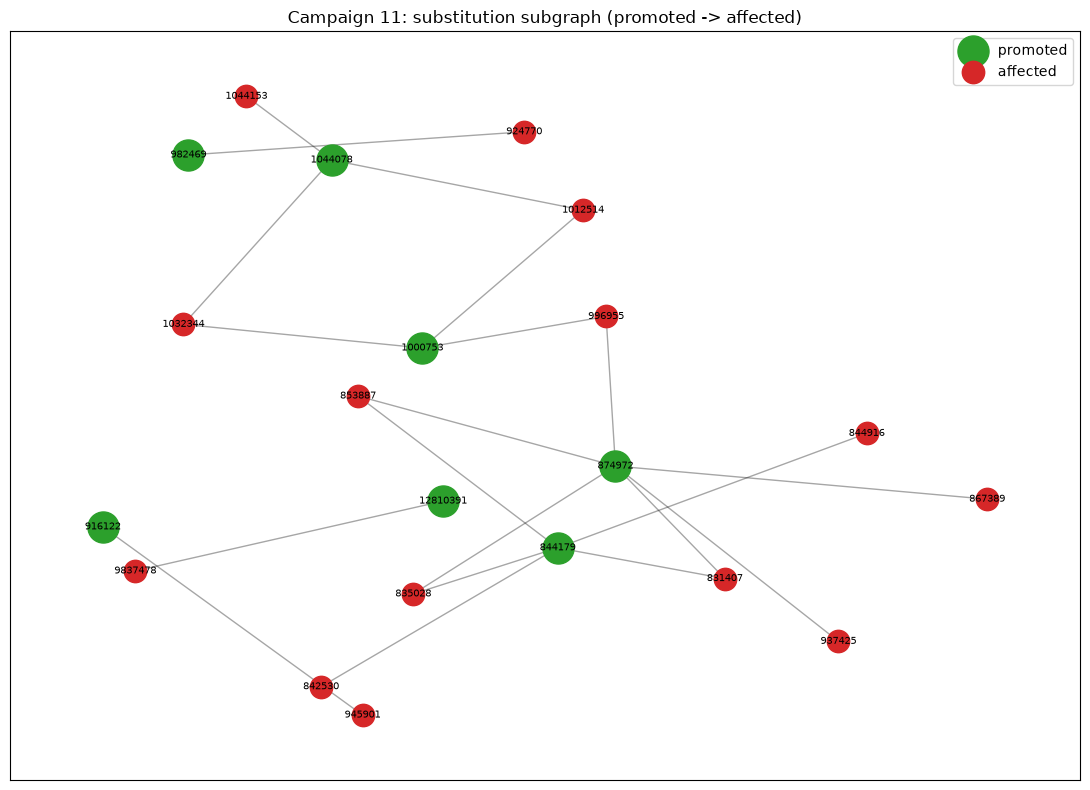

In [14]:
# Figure 2: relationship subgraph for the same campaign
import networkx as nx
subg_edges = [(r["promoted_pid"], r["affected_pid"]) for _, r in
              cann[cann["CAMPAIGN"] == top_camp].sort_values("impact_revenue", ascending=False).head(20).iterrows()]
SG = nx.Graph()
SG.add_edges_from(subg_edges)
pos = nx.spring_layout(SG, seed=CFG.seed, k=0.9)
fig, ax = plt.subplots(figsize=(11, 8))
promo_nodes = {n for n in SG if n in set(cann[cann["CAMPAIGN"] == top_camp]["promoted_pid"])}
nx.draw_networkx_nodes(SG, pos, nodelist=promo_nodes, node_color="#2ca02c",
                       node_size=500, label="promoted", ax=ax)
nx.draw_networkx_nodes(SG, pos, nodelist=[n for n in SG if n not in promo_nodes],
                       node_color="#d62728", node_size=260, label="affected", ax=ax)
nx.draw_networkx_edges(SG, pos, alpha=0.35, ax=ax)
nx.draw_networkx_labels(SG, pos, font_size=7, ax=ax)
ax.set_title(f"Campaign {top_camp}: substitution subgraph (promoted -> affected)")
ax.legend()
plt.tight_layout()
fig.savefig(CFG.figures_dir / "relationship_subgraph.png", dpi=110)
plt.show()


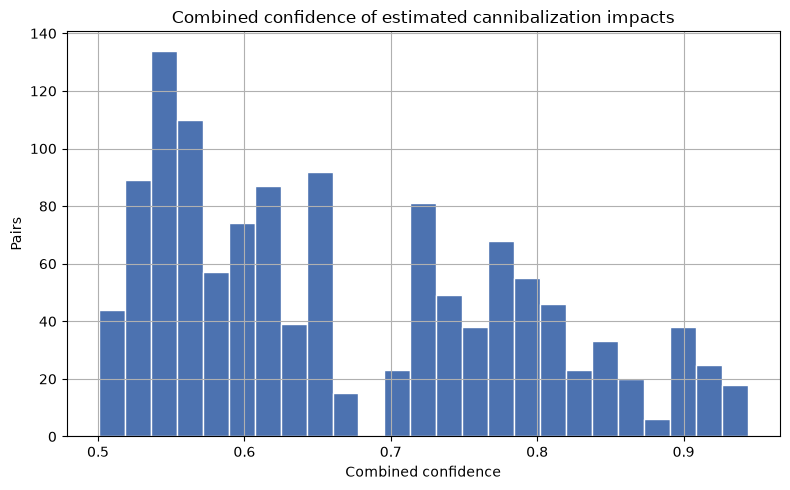

In [15]:
# Figure 3: confidence distribution of estimated impacts
fig, ax = plt.subplots(figsize=(8, 5))
cann["combined_confidence"].hist(bins=25, ax=ax, color="#4c72b0", edgecolor="white")
ax.set_title("Combined confidence of estimated cannibalization impacts")
ax.set_xlabel("Combined confidence"); ax.set_ylabel("Pairs")
plt.tight_layout()
fig.savefig(CFG.figures_dir / "confidence_distribution.png", dpi=110)
plt.show()


# ## 6. Validation — Exports, Schema and Reload


In [16]:
def validate_exports() -> None:
    out = CFG.output_dir
    a = UC.reload_and_check(out / "campaign_cannibalization.parquet",
        expected=["CAMPAIGN", "affected_pid", "lost_qty", "lost_revenue",
                  "max_confidence", "top_source", "COMMODITY_DESC"],
        context="campaign_cannibalization")
    assert a["CAMPAIGN"].nunique() == len(cann["CAMPAIGN"].unique())
    assert (a["max_confidence"].between(0, 1)).all()

    report_path = out / "cannibalization_report.json"
    assert report_path.exists(), "report json missing"
    with open(report_path) as f:
        rep = json.load(f)
    assert len(rep) == len(cann["CAMPAIGN"].unique())
    sample = next(iter(rep.values()))
    assert "affected_products" in sample and "total_estimated_lost_revenue" in sample
    print("PASS: MVP 04 exports validated")


validate_exports()


PASS [nan/inf] reload campaign_cannibalization.parquet: no NaN/Inf in 994 rows
PASS [schema] reload campaign_cannibalization.parquet: 17 columns OK
PASS [reload] campaign_cannibalization: campaign_cannibalization.parquet -> 994 rows
PASS: MVP 04 exports validated


In [17]:
# Pipeline manifest snippet
manifest = {
    "notebook": "07_cannibalization",
    "mvp": "MVP 04 — Cannibalization",
    "inputs": [
        "outputs/product_intelligence/product_relationships.parquet",
        "outputs/product_intelligence/product_pair_features.parquet",
        "outputs/product_intelligence/relationship_explanations.parquet",
        "outputs/product_intelligence/temporal_relationships.parquet",
        "outputs/product_intelligence/product_embeddings.parquet",
        "outputs/product_intelligence/product_features.parquet",
        "outputs/promotion_analysis/promoted_products.parquet",
        "outputs/promotion_analysis/product_daily.parquet",
        "outputs/promotion_analysis/campaign_summary.parquet",
        "data/raw/product.csv",
    ],
    "outputs": [
        "outputs/cannibalization/cannibalization_panel.parquet",
        "outputs/cannibalization/campaign_cannibalization.parquet",
        "outputs/cannibalization/cannibalization_report.json",
    ],
    "artifacts": {
        "cannibalization_panel.parquet": "pair-level pre/during/post panel — input for future causal inference",
        "campaign_cannibalization.parquet": "per-campaign affected products with lost volume/revenue + confidence",
        "cannibalization_report.json": "LLM/MCP-friendly business report with evidence chains",
    },
    "design_notes": [
        "reuses Product Intelligence ML relationships — no weak labels or heuristic classifiers",
        "impact estimator is transparent (pre-window mean + trend adjustment) and replaceable by a causal model on the exported panel",
    ],
}
print(json.dumps(manifest, indent=2))


{
  "notebook": "07_cannibalization",
  "mvp": "MVP 04 \u2014 Cannibalization",
  "inputs": [
    "outputs/product_intelligence/product_relationships.parquet",
    "outputs/product_intelligence/product_pair_features.parquet",
    "outputs/product_intelligence/relationship_explanations.parquet",
    "outputs/product_intelligence/temporal_relationships.parquet",
    "outputs/product_intelligence/product_embeddings.parquet",
    "outputs/product_intelligence/product_features.parquet",
    "outputs/promotion_analysis/promoted_products.parquet",
    "outputs/promotion_analysis/product_daily.parquet",
    "outputs/promotion_analysis/campaign_summary.parquet",
    "data/raw/product.csv"
  ],
  "outputs": [
    "outputs/cannibalization/cannibalization_panel.parquet",
    "outputs/cannibalization/campaign_cannibalization.parquet",
    "outputs/cannibalization/cannibalization_report.json"
  ],
  "artifacts": {
    "cannibalization_panel.parquet": "pair-level pre/during/post panel \u2014 input fo